In [21]:
from traceback import extract_stack

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from jupyter_client.jsonutil import squash_dates
from prompt_toolkit.data_structures import Size
from scipy.constants import year



DB = pd.read_csv("DS4.csv")
print(DB)


         id diagnosis  year  radius_mean  texture_mean  perimeter_mean  \
0     0032f         M     1        18.30         19.61          123.42   
1     0032f         M     5        19.17         19.87          134.35   
2     0032f         M     4        18.31         19.87          129.65   
3     0032f         M     3        18.06         19.51          124.53   
4     0032f         M     2        18.64         18.92          126.89   
...     ...       ...   ...          ...           ...             ...   
3358  ff271         M     1        19.26         19.74          117.50   
3359  ff271         M     2        19.45         20.28          120.74   
3360  ff271         M     3        19.43         21.13          126.34   
3361  ff271         M     0        19.43         20.48          121.25   
3362  ff271         M     4        19.45         21.11          128.64   

      area_mean  smoothness_mean  compactness_mean  concavity_mean  ...  \
0       1030.15             0.13    

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

DB_Alter1 = DB.copy()
DB_Alter1 = DB_Alter1.drop(columns=["id","year"])
DB_Alter1 = DB_Alter1.dropna()

estandarizar = ["radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst"]

scaler_std = StandardScaler()
DB_Alter1[estandarizar] = scaler_std.fit_transform(DB_Alter1[estandarizar])
print(DB_Alter1)


     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0            M     1.097041      0.049045        1.199394   1.065993   
1            M     1.331311      0.105441        1.623509   1.092094   
2            M     1.099734      0.105441        1.441136   1.063437   
3            M     1.032415      0.027355        1.242465   1.095900   
4            M     1.188595     -0.100620        1.334040   1.010723   
...        ...          ...           ...             ...        ...   
3358         M     1.355546      0.077243        0.969681   0.882716   
3359         M     1.406708      0.194372        1.095402   0.843579   
3360         M     1.401322      0.378742        1.312698   0.835768   
3361         M     1.401322      0.237753        1.115192   1.007770   
3362         M     1.406708      0.374404        1.401945   0.943525   

      smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0            2.170859          2.705034        3.091760

In [23]:
DB_Alter1[estandarizar] = DB_Alter1[estandarizar].round(2)

In [24]:
dic_DB_class = {
    "M": 1,
    "B": 0,
}
DB_Alter1["diagnosis"] = DB_Alter1["diagnosis"].map(dic_DB_class)

In [25]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
import tensorflow as tf


y = DB_Alter1["diagnosis"]
x = DB_Alter1.drop("diagnosis", axis=1)

#y = DB_Alter["DIAGNOSIS"]
#x = DB_Alter.drop("class", axis=1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=28,stratify=y)

print("Características de entrada:", x_train.shape[1])
print("Class:", y.nunique())

model = Sequential()
model.add(Dense(32,input_dim=x_train.shape[1],activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(16,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(1,activation="sigmoid"))
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
history = model.fit(x_train,y_train,epochs=100,batch_size=32,validation_split=0.2,verbose=1)

result = model.evaluate(x_test,y_test,verbose=1)
print("Loss:", result[0])
print("Accuracy:", result[1])


Características de entrada: 30
Class: 2
Epoch 1/100


C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6794 - loss: 0.5608 - val_accuracy: 0.9405 - val_loss: 0.3204
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9642 - loss: 0.2024 - val_accuracy: 0.9833 - val_loss: 0.0895
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9875 - loss: 0.0823 - val_accuracy: 0.9944 - val_loss: 0.0385
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9921 - loss: 0.0445 - val_accuracy: 0.9963 - val_loss: 0.0234
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9949 - loss: 0.0278 - val_accuracy: 0.9981 - val_loss: 0.0169
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9972 - loss: 0.0236 - val_accuracy: 0.9981 - val_loss: 0.0131
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9981 - loss: 0.0175 - val_accuracy: 0.9981 - val_loss: 0.0101
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9977 - loss: 0.0136 - val_accuracy: 0.9981 - val_loss: 0.0

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


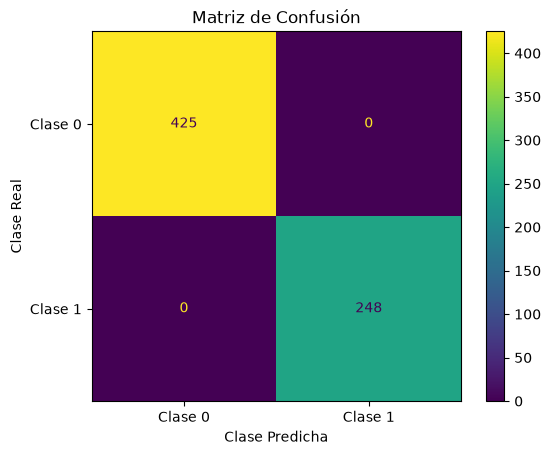

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predicciones del modelo (Probabilidades entre 0 y 1)
y_pred_probs = model.predict(x_test)

# FIX: Convertir probabilidades a la clase predicha usando un umbral de 0.5
y_pred = (y_pred_probs > 0.5).astype(int)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Clase 0", "Clase 1"]
)

disp.plot(cmap="viridis")

plt.title("Matriz de Confusión")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.show()